# Implementing / Understanding Neural-ODE

In this section I tried to understand code implementation for node and added some examples myself :')

In [1]:
import math
import numpy as np
from IPython.display import clear_output
from tqdm import tqdm_notebook as tqdm

import matplotlib as mpl
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
sns.color_palette("bright")
import matplotlib as mpl
import matplotlib.cm as cm

import torch
from torch import Tensor
from torch import nn
from torch.nn  import functional as F
from torch.autograd import Variable

In [2]:
#cr. msurtsukov
# eulers ode solver
def ode_solve(z0, t0, t1, f):
    """
    Simplest Euler ODE initial value solver
    """
    h_max = 0.05
    n_steps = math.ceil((abs(t1 - t0)/h_max).max().item())

    h = (t1 - t0)/n_steps
    t = t0
    z = z0

    for i_step in range(n_steps):
        z = z + h * f(z, t)
        t = t + h
    return z

In [2]:
# rk ode solver
def ode_solve(z0, t0, t1, f):
    """
    Runge-Kutta 2nd order ODE initial value solver
    """
    h_max = 0.05
    n_steps = math.ceil((abs(t1 - t0)/h_max).max().item())

    h = (t1 - t0)/n_steps
    t = t0
    z = z0

    for i_step in range(n_steps):
        f1 = f(z,t)
        f2 = f(z + (h/2) * f1, t + h/2)

        z = z + h * f2
        t = t + h

    return z


#### implementation code from msurtsukov

In [3]:
class ODEF(nn.Module):
    def forward_with_grad(self, z, t, grad_outputs):
        """Compute f and a df/dz, a df/dp, a df/dt"""
        batch_size = z.shape[0]

        out = self.forward(z, t)

        a = grad_outputs
        #print('these are initial grad outputs :', grad_outputs)
        adfdz, adfdt, *adfdp = torch.autograd.grad(  # gradients needed to find da_aug/dt using the adjoint state
            (out,), (z, t) + tuple(self.parameters()), grad_outputs=(a),
            allow_unused=True, retain_graph=True
        )
        #print('these are grad outputs after :', grad_outputs)
        # grad method automatically sums gradients for batch items, we have to expand them back 
        if adfdp is not None:
            adfdp = torch.cat([p_grad.flatten() for p_grad in adfdp]).unsqueeze(0)
            adfdp = adfdp.expand(batch_size, -1) / batch_size
        if adfdt is not None:
            adfdt = adfdt.expand(batch_size, 1) / batch_size
        return out, adfdz, adfdt, adfdp

    def flatten_parameters(self):
        p_shapes = []
        flat_parameters = []
        for p in self.parameters():
            p_shapes.append(p.size())
            flat_parameters.append(p.flatten()) #makes 2d tensor into 1d
        return torch.cat(flat_parameters)

we flatten because the adjoint method needs to treat all parameters as one flat vector to solve the adjoint ODE alongside the original ODE

In [4]:
class ODEAdjoint(torch.autograd.Function):
    @staticmethod
    def forward(ctx, z0, t, flat_parameters, func):
        '''calling the ode solver for each time step'''
        assert isinstance(func, ODEF)
        bs, *z_shape = z0.size()
        time_len = t.size(0)

        with torch.no_grad(): #we don't save gradients for back pass like for other types of nn (we did that in the above cell)
            z = torch.zeros(time_len, bs, *z_shape).to(z0)
            z[0] = z0
            for i_t in range(time_len - 1):
                z0 = ode_solve(z0, t[i_t], t[i_t+1], func)
                z[i_t+1] = z0

        ctx.func = func
        ctx.save_for_backward(t, z.clone(), flat_parameters) #ctx is what is saved and will be used for backprop later (since we have to build a new backprop method)
        return z

    @staticmethod
    def backward(ctx, dLdz): #now we will do back prop using what we saved with ctx and find the gradient of the loss w.r.t. our IVP sol
        """
        dLdz shape: time_len, batch_size, *z_shape
        """
        func = ctx.func
        t, z, flat_parameters = ctx.saved_tensors
        time_len, bs, *z_shape = z.size()
        n_dim = np.prod(z_shape)
        n_params = flat_parameters.size(0)

        # Dynamics of augmented system to be calculated backwards in time
        def augmented_dynamics(aug_z_i, t_i):
            """
            tensors here are temporal slices
            t_i - is tensor with size: bs, 1
            aug_z_i - is tensor with size: bs, n_dim*2 + n_params + 1
            """
            z_i, a = aug_z_i[:, :n_dim], aug_z_i[:, n_dim:2*n_dim]  # ignore parameters and time

            # Unflatten z and a
            z_i = z_i.view(bs, *z_shape)
            a = a.view(bs, *z_shape)
            with torch.set_grad_enabled(True): # we are tracking gradients again since we will need it for
                t_i = t_i.detach().requires_grad_(True)
                z_i = z_i.detach().requires_grad_(True)
                # this line is when we are calculating gradients:
                func_eval, adfdz, adfdt, adfdp = func.forward_with_grad(z_i, t_i, grad_outputs=a)  # bs, *z_shape
                adfdz = adfdz.to(z_i) if adfdz is not None else torch.zeros(bs, *z_shape).to(z_i)
                adfdp = adfdp.to(z_i) if adfdp is not None else torch.zeros(bs, n_params).to(z_i)
                adfdt = adfdt.to(z_i) if adfdt is not None else torch.zeros(bs, 1).to(z_i)

            # Flatten f and adfdz
            func_eval = func_eval.view(bs, n_dim)
            adfdz = adfdz.view(bs, n_dim) 
            return torch.cat((func_eval, -adfdz, -adfdp, -adfdt), dim=1) #flatten all gradients

        dLdz = dLdz.view(time_len, bs, n_dim)  # flatten dLdz for convenience
        with torch.no_grad():
            ## Create placeholders for output gradients
            # Prev computed backwards adjoints to be adjusted by direct gradients
            adj_z = torch.zeros(bs, n_dim).to(dLdz)
            adj_p = torch.zeros(bs, n_params).to(dLdz)
            # In contrast to z and p we need to return gradients for all times
            adj_t = torch.zeros(time_len, bs, 1).to(dLdz)

            for i_t in range(time_len-1, 0, -1):
                z_i = z[i_t]
                t_i = t[i_t]
                f_i = func(z_i, t_i).view(bs, n_dim)

                # Compute direct gradients
                dLdz_i = dLdz[i_t]
                dLdt_i = torch.bmm(torch.transpose(dLdz_i.unsqueeze(-1), 1, 2), f_i.unsqueeze(-1))[:, 0]

                # Adjusting adjoints with direct gradients
                adj_z += dLdz_i
                adj_t[i_t] = adj_t[i_t] - dLdt_i

                # Pack augmented variable
                aug_z = torch.cat((z_i.view(bs, n_dim), adj_z, torch.zeros(bs, n_params).to(z), adj_t[i_t]), dim=-1)

                # Solve augmented system backwards
                aug_ans = ode_solve(aug_z, t_i, t[i_t-1], augmented_dynamics) #calling ode solver cause for back prop we're essentially solving another ode (just back in time)

                # Unpack solved backwards augmented system
                adj_z[:] = aug_ans[:, n_dim:2*n_dim]
                adj_p[:] += aug_ans[:, 2*n_dim:2*n_dim + n_params]
                adj_t[i_t-1] = aug_ans[:, 2*n_dim + n_params:]

                del aug_z, aug_ans

            ## Adjust 0 time adjoint with direct gradients
            # Compute direct gradients 
            dLdz_0 = dLdz[0]
            dLdt_0 = torch.bmm(torch.transpose(dLdz_0.unsqueeze(-1), 1, 2), f_i.unsqueeze(-1))[:, 0]

            # Adjust adjoints
            adj_z += dLdz_0
            adj_t[0] = adj_t[0] - dLdt_0
        return adj_z.view(bs, *z_shape), adj_t, adj_p, None

In [5]:
class NeuralODE(nn.Module):
    def __init__(self, func):
        super(NeuralODE, self).__init__()
        assert isinstance(func, ODEF)
        self.func = func

    def forward(self, z0, t=Tensor([0., 1.]), return_whole_sequence=False):
        t = t.to(z0)
        z = ODEAdjoint.apply(z0, t, self.func.flatten_parameters(), self.func)
        if return_whole_sequence:
            return z
        else:
            return z[-1]

## Application

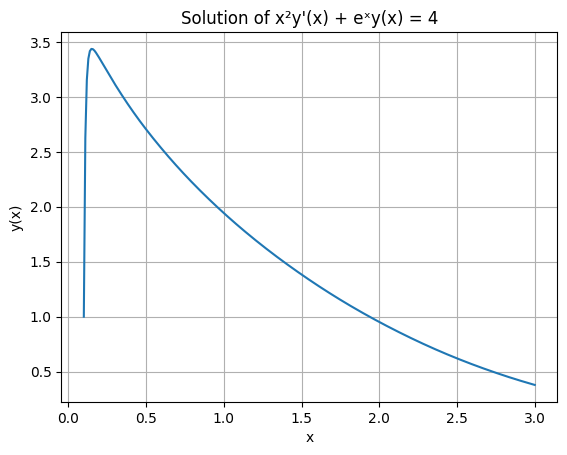

  message: The solver successfully reached the end of the integration interval.
  success: True
   status: 0
        t: [ 1.000e-01  1.097e-01 ...  2.990e+00  3.000e+00]
        y: [[ 1.000e+00  2.626e+00 ...  3.829e-01  3.790e-01]]
      sol: <scipy.integrate._ivp.common.OdeSolution object at 0x1198892b0>
 t_events: None
 y_events: None
     nfev: 92
     njev: 0
      nlu: 0


In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

def ode_ex1(x, y):
    return (4 - np.exp(x) * y[0]) / x**2

# initial condition and range
x_span = (0.1, 3)   # start from 0.1 to avoid division by zero at x=0
x_eval = np.linspace(0.1, 3, 300)
y0 = [1.0]           # initial condition y(0.1) = 1, change as needed

# solve
sol_ex1 = solve_ivp(ode_ex1, x_span, y0, t_eval=x_eval, dense_output=True)

# plot
plt.plot(sol_ex1.t, sol_ex1.y[0])
plt.xlabel("x")
plt.ylabel("y(x)")
plt.title("Solution of x²y'(x) + eˣy(x) = 4")
plt.grid(True)
plt.show()

print(sol_ex1)

In [7]:
def random_ex1(sol_ex1, n):
    indices = np.random.choice(len(sol_ex1.t), n, replace=False)
    indices = np.sort(indices)
    x_vals = sol_ex1.t[indices]
    y_vals = sol_ex1.y[0][indices]
    return x_vals, y_vals
    


In [8]:
random_ex1(sol_ex1, 10)

(array([0.21638796, 0.27458194, 0.78862876, 1.16688963, 1.18628763,
        1.20568562, 2.1270903 , 2.37926421, 2.7187291 , 2.96120401]),
 array([3.31317909, 3.1735889 , 2.23273345, 1.73895588, 1.71648606,
        1.69426145, 0.85880007, 0.69187571, 0.50476283, 0.39480446]))

In [9]:
class LinearODEF1D(ODEF):
    def __init__(self):
        super(LinearODEF1D, self).__init__()
        self.lin = nn.Linear(1, 1, bias=True)

    def forward(self, z, t):
        return self.lin(z)
    
ode_trained = NeuralODE(LinearODEF1D())

In [10]:
x_vals, y_vals = random_ex1(sol_ex1, 30)

t_tensor = torch.Tensor(x_vals)               # time points
y_tensor = torch.Tensor(y_vals).unsqueeze(1)  # observations, shape (30, 1)
z0 = y_tensor[0].unsqueeze(0)                 # initial condition, shape (1, 1)

In [11]:
optimizer = torch.optim.Adam(ode_trained.parameters(), lr=0.01)

for epoch in range(1000):
    optimizer.zero_grad()
    pred = ode_trained(z0, t_tensor, return_whole_sequence=True).squeeze()
    loss = ((pred - y_tensor.squeeze()) ** 2).mean()
    loss.backward()
    optimizer.step()
    if epoch % 200 == 0:
        print(f'Epoch {epoch} | Loss: {loss.item():.6f}')

Epoch 0 | Loss: 0.158076
Epoch 200 | Loss: 0.000929
Epoch 400 | Loss: 0.000921
Epoch 600 | Loss: 0.000921
Epoch 800 | Loss: 0.000921


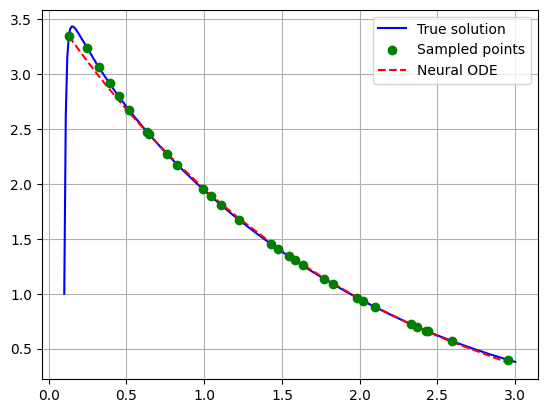

In [12]:
with torch.no_grad():
    pred_final = ode_trained(z0, t_tensor, return_whole_sequence=True).squeeze().numpy()

plt.plot(sol_ex1.t, sol_ex1.y[0], label='True solution', color='blue')
plt.scatter(x_vals, y_vals, label='Sampled points', color='green', zorder=3)
plt.plot(x_vals, pred_final, label='Neural ODE', color='red', linestyle='--')
plt.legend()
plt.grid(True)
plt.show()

In [50]:
class PendulumODEF(ODEF):
    def __init__(self, g=9.81, L=1.0):
        super(PendulumODEF, self).__init__()
        self.g = g
        self.L = L

    def forward(self, x, t):
        # x[:, 0] = theta (angle)
        # x[:, 1] = omega (angular velocity)
        theta = x[:, 0]
        omega = x[:, 1]
        
        dtheta = omega
        domega = -(self.g / self.L) * torch.sin(theta)
        
        return torch.stack([dtheta, domega], dim=1)

In [ ]:
class RandomPendulumODEF(PendulumODEF):
    def __init__(self):
        super(RandomPendulumODEF, self).__init__(torch.randn(2, 2)/2.)